# Waste Sorting with Deep Learning: A CNN Classifier for Recyclables

A DenseNet121-based image classifier for sorting cardboard, glass, metal, and plastic waste, with a focus on real-world generalisation across a controlled baseline, an augmentation study, and a domain-shift evaluation against images from an actual waste recovery facility.


## Project details

- **Author:** Danny Vo
- **Date:** 2026


## Project scope

- Single recycling image-classification problem, evaluated across three stages: a transfer-learning baseline, a controlled data-augmentation study, and a domain-shift/generalisation test.
- One CNN backbone (DenseNet121, ImageNet-pretrained) kept constant across all three stages so results are comparable.
- Every stage reports accuracy and macro-F1, using the same train/validation/test split throughout.


## Environment and imports

In [2]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm
import torch
import shutil
import gdown
import zipfile
from torchinfo import summary
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from collections import Counter

import torchvision.transforms.v2 as T
from torchvision import transforms, datasets
from torchvision.models import densenet121, DenseNet121_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

## Reproducibility

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Seed set to {SEED}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Seed set to 42
Device: cuda


# I. Problem setup and baseline model


## 1 Define the problem and dataset

**Problem summary**

This project addresses the critical issue of waste classification for better recycling decisions by developing a CNN-based classifier to minimize the sorting error across four common recycle materials, including cardboard, glass, metal, and plastic.The TrashNet dataset is used to train and evaluate the CNN model. Specifically, the model takes RGB images of waste items as input and predicts one of the four target classes as output. There are 1796 images in the dataset, which will be split into 70% training, 15% validation, and 15% testing. This distribution is appropriate as it provides enough samples for model training while keeping separate validation and test sets for evaluation. Model performance will be evaluated using accuracy, macro-F1 score, and a confusion matrix to assess both overall reliability and class-wise classification behaviour.


**Problem setup table**

| Item | Your response |
| --- | --- |
| Recycling objective | To improve the accuracy of classifying common waste materials, reduce the contamination caused by sorting errors and ensuring recyclable item are placed in the correct bins to support environmental sustainability. |
| Input image type | RGB images of individual waste items, resized to a fixed image size before being passed into the CNN model. |
| Target classes | Cardboard, Glass, Metal, Plastic|
| Dataset source(s) | The main dataset is built from the TrashNet dataset, which is available from the GitHub repository by Gary Thung and Mindy Yang. |
| Whether additional manual labelling was required | No addtionally manual labeling is required, since the images are already classified into four different labels|
| Total number of images | 1,796 images in total, including 403 cardboard images, 501 glass images, 410 metal images, and 482 plastic images |
| Train / validation / test split | A stratified 70% Train (1257), 15% Validation (269), 15% Test (270) split is used|
| Success criteria | The model should achieve reasonable macro-F1 on the independent test set while maintaining balanced performance across the four target classes. A macro-F1 score of around 0.80 is used as an indicative benchmark for evaluating the reliablity of model performance.|

- Implement data summary and class counts

In [4]:
file_id = "1T92ABsXQtaxUpkeRCdRiKjq3-y2GeRqR"
url = f"https://drive.google.com/uc?id={file_id}"

# Download zip file
gdown.download(url, "/content/dataset-resized.zip", quiet=False)

# Unzip file
!unzip -qo /content/dataset-resized.zip -d /content/dataset-resized

# Define dataset path
path = "/content/dataset-resized/dataset-resized"

# Load dataset
trashnet5 = datasets.ImageFolder(root=path, transform=None)

print("Classes:", trashnet5.classes)
print("Number of images:", len(trashnet5))

Downloading...
From (original): https://drive.google.com/uc?id=1T92ABsXQtaxUpkeRCdRiKjq3-y2GeRqR
From (redirected): https://drive.google.com/uc?id=1T92ABsXQtaxUpkeRCdRiKjq3-y2GeRqR&confirm=t&uuid=651892e1-c2c7-4eb4-9a40-bc4b61ac83d1
To: /content/dataset-resized.zip
100%|██████████| 42.8M/42.8M [00:00<00:00, 114MB/s]


Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of images: 2527


In [5]:
!find /content/dataset-resized -maxdepth 3 -type d

/content/dataset-resized
/content/dataset-resized/__MACOSX
/content/dataset-resized/__MACOSX/dataset-resized
/content/dataset-resized/__MACOSX/dataset-resized/cardboard
/content/dataset-resized/dataset-resized
/content/dataset-resized/dataset-resized/plastic
/content/dataset-resized/dataset-resized/glass
/content/dataset-resized/dataset-resized/cardboard
/content/dataset-resized/dataset-resized/trash
/content/dataset-resized/dataset-resized/paper
/content/dataset-resized/dataset-resized/metal


In [6]:
# Original dataset path after unzip
path = "/content/dataset-resized/dataset-resized"

# Choose only 4 classes
selected_classes = ["cardboard", "glass", "metal", "plastic"]

# Create new folder for 4-class dataset
filtered_path = "/content/trashnet_4classes"

# Remove old filtered folder if it already exists
if os.path.exists(filtered_path):
    shutil.rmtree(filtered_path)

os.makedirs(filtered_path, exist_ok=True)

# Copy only selected class folders
for class_name in selected_classes:
    src = os.path.join(path, class_name)
    dst = os.path.join(filtered_path, class_name)

    if os.path.exists(src):
        shutil.copytree(src, dst)
    else:
        print(f"Missing class folder: {class_name}")

# Load 4-class dataset
trashnet4 = datasets.ImageFolder(root=filtered_path, transform=None)

print("Classes:", trashnet4.classes)
print("Class to index:", trashnet4.class_to_idx)
print("Number of images:", len(trashnet4))

# Count images per class using ImageFolder targets
label_counts = Counter(trashnet4.targets)

# Create list to store class information
class_counts = []

for class_name, class_idx in trashnet4.class_to_idx.items():
    count = label_counts[class_idx]

    class_counts.append({
        "Class": class_name,
        "Number of Images": count
    })

# Convert to DataFrame
class_counts_df = pd.DataFrame(class_counts)

# Add percentage column
total_images = class_counts_df["Number of Images"].sum()

class_counts_df["Percentage (%)"] = (
    class_counts_df["Number of Images"] / total_images * 100
).round(2)

# Display summary table
display(class_counts_df)

Classes: ['cardboard', 'glass', 'metal', 'plastic']
Class to index: {'cardboard': 0, 'glass': 1, 'metal': 2, 'plastic': 3}
Number of images: 1796


,Class,Number of Images,Percentage (%)
0,cardboard,403,22.44
1,glass,501,27.90
2,metal,410,22.83
3,plastic,482,26.84


## 2 Baseline model

The baseline model used in this project is DenseNet121, a CNN-based image classification model. DenseNet121 was selected because its dense connectivity promotes feature reuse. Accordingly, it can help distinguish visual textures across recyclable materials such as glass, metal, cardboard, and plastic. To apply transfer learning and prevent overfitting on the relatively small TrashNet subset, ImageNet-1K pre-trained weights were used. Specifically, the convolutional feature extractor was frozen to preserve general visual features learned from ImageNet, while the final classifier layer was replaced and trained for the four target classes. Input images were resized to 224 × 224 RGB images and normalised using ImageNet statistics. The baseline model was trained using Cross-Entropy Loss and the Adam optimiser with a learning rate of 0.001, batch size of 32, and 10 epochs.



In [8]:
# Model and Dataset Configuration
# Selected classes for this assignment
class_names = ["Cardboard", "Glass", "Metal", "Plastic"]

# Model and training configuration
NUM_CLASSES = len(selected_classes)
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001

valid_extensions = (".jpg", ".jpeg", ".png")


In [9]:
# Define the function the ensure the dataset in good form for CNN model
class WasteDataset(Dataset):
    def __init__(self, root_dir, selected_classes, transform=None):
        self.root_dir = root_dir
        self.selected_classes = selected_classes
        self.transform = transform

        self.class_to_idx = {
            class_name: idx for idx, class_name in enumerate(selected_classes)
        }

        self.image_paths = []
        self.labels = []

        for class_name in selected_classes:
            class_folder = os.path.join(root_dir, class_name)

            if not os.path.exists(class_folder):
                raise FileNotFoundError(
                    f"Folder not found: {class_folder}\n"
                    f"Please check DATA_DIR and class folder names."
                )

            for file_name in sorted(os.listdir(class_folder)):
                if file_name.lower().endswith(valid_extensions):
                    self.image_paths.append(os.path.join(class_folder, file_name))
                    self.labels.append(self.class_to_idx[class_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [10]:
# Baseline preprocessing without data augmentation
baseline_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop((IMAGE_SIZE, IMAGE_SIZE)),

    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),

    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
# Original dataset path after unzip
root = "/content/dataset-resized/dataset-resized"


# Load the dataset with baseline preprocessing
full_dataset = WasteDataset(
    root_dir=root,
    selected_classes=selected_classes,
    transform=baseline_transform
)

# Create labels from full dataset
labels = np.array(full_dataset.labels)

print("Total number of images loaded:", len(full_dataset))

Total number of images loaded: 1796


In [12]:
# Split the dataset into 70% training set, 15% validation set, and 15% test set

# Create image indices and labels
X = np.arange(len(full_dataset))
y = labels

# Split the full dataset into 70% train set and 30% temporary set
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Split the temporary set into 15% validation set and 15% test set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

# Create PyTorch subset datasets using the split indices
train_dataset = Subset(full_dataset, X_train)
val_dataset = Subset(full_dataset, X_val)
test_dataset = Subset(full_dataset, X_test)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

print("\nNumber of images:")
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Training set: (1257,) (1257,)
Validation set: (269,) (269,)
Test set: (270,) (270,)

Number of images:
Training images: 1257
Validation images: 269
Test images: 270


In [13]:
g = torch.Generator()
g.manual_seed(SEED)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [15]:
# Define input and output dimensions
input_channels = 3
image_size = 224
output_dim = len(np.unique(y_train))

print("Input image shape:", f"{input_channels} x {image_size} x {image_size}")
print("Output dimension:", output_dim)

Input image shape: 3 x 224 x 224
Output dimension: 4


In [16]:
# Define DenseNet121 baseline model
class DenseNet121Baseline(nn.Module):
    def __init__(self, output_dim):
        super().__init__()

        # Load DenseNet121 with ImageNet pre-trained weights
        weights = DenseNet121_Weights.IMAGENET1K_V1
        self.network = densenet121(weights=weights)

        # Freeze feature extractor layers
        for param in self.network.features.parameters():
            param.requires_grad = False

        # Replace the final classifier layer for the selected classes
        in_features = self.network.classifier.in_features
        self.network.classifier = nn.Linear(in_features, output_dim)

    def forward(self, x):
        return self.network(x)

# Reset seed before model initialisation
torch.manual_seed(SEED)

# Create the model
model = DenseNet121Baseline(output_dim=output_dim)

# Move model to GPU or CPU
model = model.to(device)

print("\nUsing DenseNet121 with ImageNet pre-trained weights.")
print("Final classifier layer:")
print(model.network.classifier)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 165MB/s]



Using DenseNet121 with ImageNet pre-trained weights.
Final classifier layer:
Linear(in_features=1024, out_features=4, bias=True)


In [ ]:
# Print Model Summary and Architecture of DenseNet121 Baseline Model
print("\n" + "="*60)
print("DenseNet121 Baseline Model Summary")
print("=" * 60)

summary(
    model,
    input_size=(BATCH_SIZE, input_channels, image_size, image_size),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=3
)


DenseNet121 Baseline Model Summary


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
DenseNet121Baseline                           [32, 3, 224, 224]         [32, 4]                   --                        Partial
├─DenseNet: 1-1                               [32, 3, 224, 224]         [32, 4]                   --                        Partial
│    └─Sequential: 2-1                        [32, 3, 224, 224]         [32, 1024, 7, 7]          --                        False
│    │    └─Conv2d: 3-1                       [32, 3, 224, 224]         [32, 64, 112, 112]        (9,408)                   False
│    │    └─BatchNorm2d: 3-2                  [32, 64, 112, 112]        [32, 64, 112, 112]        (128)                     False
│    │    └─ReLU: 3-3                         [32, 64, 112, 112]        [32, 64, 112, 112]        --                        --
│    │    └─MaxPool2d: 3-4                    [32, 64, 112, 112]        [32, 64, 56, 

In [18]:
# Create function to evaluate the model
def evaluate_model(model, loader, criterion, device):
    # Switch to evaluation mode
    model.eval()

    # Initialise accumulators
    total_loss = 0.0
    total_items = 0

    # Create lists to store all predictions and true labels
    all_preds = []
    all_labels = []

    with torch.no_grad():
        # Loop through each batch
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # Compute model output and loss
            logits = model(xb)
            loss = criterion(logits, yb)

            # Get predicted class
            preds = torch.argmax(logits, dim=1)

            # Update total loss and item count
            batch_size_current = xb.size(0)
            total_loss += loss.item() * batch_size_current
            total_items += batch_size_current

            # Store predictions and labels for accuracy and macro-F1
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    # Compute average loss, accuracy, and macro-F1
    avg_loss = total_loss / total_items
    avg_acc = accuracy_score(all_labels, all_preds)
    avg_macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return avg_loss, avg_acc, avg_macro_f1, all_labels, all_preds


# Create a function to train the model
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):
    # Create a dictionary to store training and validation history
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_macro_f1": [],
        "val_macro_f1": [],
        "epoch_time": []
    }

    model = model.to(device)

    # Loop to train for specific number of epochs
    for epoch in range(epochs):
        # Switch model to training mode
        model.train()

        # Start timer for training time per epoch
        start_time = time.time()

        # Initialise accumulators for the current epoch
        running_loss = 0.0
        total_items = 0

        # Create lists to store predictions and labels
        train_preds = []
        train_labels = []

        # Loop through each mini-batch
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # Reset gradients
            optimizer.zero_grad()

            # Forward pass
            logits = model(xb)

            # Compute loss
            loss = criterion(logits, yb)

            # Backward pass and update parameters
            loss.backward()
            optimizer.step()

            # Get predicted class
            preds = torch.argmax(logits, dim=1)

            # Update total loss and item count
            batch_size_current = xb.size(0)
            running_loss += loss.item() * batch_size_current
            total_items += batch_size_current

            # Store predictions and labels
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(yb.cpu().numpy())

        # Compute training time for this epoch
        epoch_time = time.time() - start_time

        # Compute average training loss, accuracy, and macro-F1
        train_loss = running_loss / total_items
        train_acc = accuracy_score(train_labels, train_preds)
        train_macro_f1 = f1_score(train_labels, train_preds, average="macro", zero_division=0)

        # Evaluate model on validation set
        val_loss, val_acc, val_macro_f1, _, _ = evaluate_model(
            model, val_loader, criterion, device
        )

        # Save metrics into dictionary
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_macro_f1"].append(train_macro_f1)
        history["val_macro_f1"].append(val_macro_f1)
        history["epoch_time"].append(epoch_time)

        # Print the results
        print(
            f"Epoch {epoch+1:02d} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | "
            f"train_macro_f1={train_macro_f1:.4f} | val_macro_f1={val_macro_f1:.4f} | "
            f"time={epoch_time:.2f}s"
        )

    return model, history

# Create a functino to plot learning curve
def plot_history(history, model_name="Model", figure_no=None):
    epochs = range(1, len(history["train_loss"]) + 1)

    # Create figure titles
    if figure_no is not None:
        loss_title = f"Figure {figure_no}(a). {model_name} Loss Curves"
        acc_title = f"Figure {figure_no}(b). {model_name} Accuracy Curves"
    else:
        loss_title = f"{model_name} Loss Curves"
        acc_title = f"{model_name} Accuracy Curves"

    # Plot Train Loss vs Validation Loss
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(loss_title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot Train Accuracy vs Validation Accuracy
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], marker="o", label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(acc_title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Create a function to calculate the gap
def generalisation_gap(history):
    return history["val_loss"][-1] - history["train_loss"][-1]

# Create a function to create comparision table
def create_result_row(setting_name, model, history, loader, criterion, device):
    # Evaluate model on validation or test set
    loss, acc, macro_f1, y_true, y_pred = evaluate_model(
        model, loader, criterion, device
    )

    # Calculate training time
    avg_epoch_time = np.mean(history["epoch_time"])
    total_training_time = np.sum(history["epoch_time"]) / 60

    return {
        "Setting": setting_name,
        "Accuracy": round(acc, 4),
        "Macro-F1": round(macro_f1, 4),
        "Training time per epoch (s)": round(avg_epoch_time, 2),
        "Total training time (min)": round(total_training_time, 2)
    }

In [19]:
# Define loss function
criterion = nn.CrossEntropyLoss()

# Define optimiser
optimizer = optim.Adam(
    model.network.classifier.parameters(),
    lr=LEARNING_RATE,
    weight_decay = 0
)

In [20]:
# Train DenseNet121 baseline model
baseline_model, baseline_history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS
)

Epoch 01 | train_loss=1.0822 | val_loss=0.7612 | train_acc=0.5521 | val_acc=0.7770 | train_macro_f1=0.5587 | val_macro_f1=0.7842 | time=12.11s
Epoch 02 | train_loss=0.6595 | val_loss=0.5848 | train_acc=0.8011 | val_acc=0.8216 | train_macro_f1=0.8052 | val_macro_f1=0.8266 | time=9.27s
Epoch 03 | train_loss=0.5587 | val_loss=0.5054 | train_acc=0.8115 | val_acc=0.8178 | train_macro_f1=0.8141 | val_macro_f1=0.8247 | time=9.34s
Epoch 04 | train_loss=0.4717 | val_loss=0.4629 | train_acc=0.8528 | val_acc=0.8439 | train_macro_f1=0.8565 | val_macro_f1=0.8485 | time=9.98s
Epoch 05 | train_loss=0.4318 | val_loss=0.4582 | train_acc=0.8648 | val_acc=0.8290 | train_macro_f1=0.8681 | val_macro_f1=0.8299 | time=12.53s
Epoch 06 | train_loss=0.3920 | val_loss=0.4099 | train_acc=0.8632 | val_acc=0.8550 | train_macro_f1=0.8666 | val_macro_f1=0.8605 | time=9.64s
Epoch 07 | train_loss=0.3698 | val_loss=0.4088 | train_acc=0.8870 | val_acc=0.8662 | train_macro_f1=0.8891 | val_macro_f1=0.8713 | time=11.49s
Epo

In [21]:
# Save the trained baseline model
folder_path = "/content/drive/MyDrive/Deep Learning/Deakin"
os.makedirs(folder_path, exist_ok=True)

save_path = os.path.join(folder_path, "baseline_model.pth")

torch.save(baseline_model.state_dict(), save_path)

print("Baseline model saved successfully!")

Baseline model saved successfully!


In [22]:
# Evaluate final model on validation set
val_loss, val_acc, val_macro_f1, val_true, val_pred = evaluate_model(
    baseline_model, val_loader, criterion, device
)

# Evaluate final model on test set
test_loss, test_acc, test_macro_f1, test_true, test_pred = evaluate_model(
    baseline_model, test_loader, criterion, device
)

# Calculate average training time per epoch
avg_epoch_time = np.mean(baseline_history["epoch_time"])

In [23]:
baseline_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro-F1",
        "Training time per epoch (seconds)"
    ],
    "Validation": [
        round(val_acc, 4),
        round(val_macro_f1, 4),
        round(avg_epoch_time, 2)
    ],
    "Test": [
        round(test_acc, 4),
        round(test_macro_f1, 4),
        "N/A"
    ]
})

print('Table 1: Baseline Model Performance on Validation and Test Sets')
display(baseline_results)

Table 1: Baseline Model Performance on Validation and Test Sets


,Metric,Validation,Test
0,Accuracy,0.8810,0.8593
1,Macro-F1,0.8847,0.863
2,Training time per epoch (seconds),10.4600,N/A


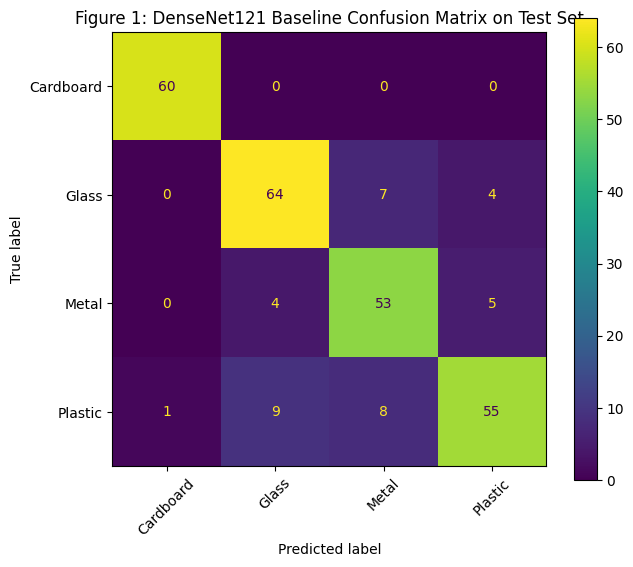

In [24]:
# Plot confusion matrix
cm = confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Figure 1: DenseNet121 Baseline Confusion Matrix on Test Set")
plt.xticks(rotation=45)
plt.show()

**Baseline results**

| Metric | Validation | Test |
| --- | ---: | ---: |
| Accuracy | 0.8810 |  0.8593 |
| Macro-F1 | 0.8847 | 0.863 |

**Training time per epoch:**  10.4600 seconds

**Brief interpretation**

The baseline mode achieved strong performance, which reached 0.8593 accuracy and a 0.863 Macro-F1 score on the test set. The validation results were slightly higher, suggesting that the model generalised reasonably well to unseen same-domain images. However, class-wise performance reveals some biases. According to the confusion matrix, the model perfectly classifies Cardboard (60/60) due to distinct matte texture. Conversely, classification of plastic, glass and metal occurs errors, especially plastic.Specifically, plastic was misclassified as glass (9 times) and metal (8 times). This is reasonable since these materials share similar shapes, reflective surfaces and textures. These errors are the primary target for the future augmentation.


# II Controlled model improvement

## 1 Data augmentation

**Augmentation design**

This augmentation pipeline simulates real-world variations in waste disposal to reduce overfitting, which is only applied to the training datasets. Specifically, the random resizes cropping was used to reduce the model's sensitivity to object scale and position, which forced the model to learn material textures. Horizontal and vertical flipping, along with small random rotations were applied since the waste items are taken in different orientations and camera angle variations. Additionally, colour jitter was implemented to stimulate the diverse environmental light, brightness, contrast, and saturation conditions, such as indoor kitchen or outdoor envrionment. These augmentations are necessary because waste images were taken with different backgrounds, viewpoints, positions, rotations, and lighting conditions.

In [25]:
# Define the augmentation pipeline for the training set only
augmentation_transform = T.Compose([
    T.ToImage(),

    T.RandomResizedCrop(
        size=(IMAGE_SIZE, IMAGE_SIZE),
        scale=(0.80, 1.0),
        ratio=(0.9, 1.1),
        antialias=True
    ),

    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),

    T.RandomAffine(
        degrees=15,
        translate=(0.08, 0.08)
    ),

    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    T.ToDtype(torch.float32, scale=True),

    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [26]:
# Create a new full dataset with augmentation transform
# This is used only for the training subset

augmented_full_dataset = WasteDataset(
    root_dir=root,
    selected_classes=selected_classes,
    transform=augmentation_transform
)

# Use the same training indices from Task 1.2
aug_train_dataset = Subset(augmented_full_dataset, X_train)

In [27]:
# Set generator for augmented training loader
g_aug = torch.Generator()
g_aug.manual_seed(SEED)

# Create augmented train loader
aug_train_loader = DataLoader(
    aug_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g_aug,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

In [28]:
# Create a new DenseNet121 model for Task 2
augmented_model = DenseNet121Baseline(output_dim=output_dim)
augmented_model = augmented_model.to(device)

# Define loss function
aug_criterion = nn.CrossEntropyLoss()

# Define optimiser
# Since DenseNet feature extractor is frozen, only train the final classifier layer
aug_optimizer = optim.Adam(
    augmented_model.network.classifier.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0
)

In [29]:
# Train and evaluate the augmented model here old
augmented_model, augmented_history = train_model(
    model=augmented_model,
    train_loader=aug_train_loader,
    val_loader=val_loader,
    criterion=aug_criterion,
    optimizer=aug_optimizer,
    device=device,
    epochs=EPOCHS
)

Epoch 01 | train_loss=1.1652 | val_loss=0.8951 | train_acc=0.4932 | val_acc=0.6914 | train_macro_f1=0.4994 | val_macro_f1=0.7036 | time=12.74s
Epoch 02 | train_loss=0.7644 | val_loss=0.7049 | train_acc=0.7430 | val_acc=0.7695 | train_macro_f1=0.7495 | val_macro_f1=0.7778 | time=15.60s
Epoch 03 | train_loss=0.6409 | val_loss=0.6109 | train_acc=0.7860 | val_acc=0.8067 | train_macro_f1=0.7896 | val_macro_f1=0.8131 | time=15.14s
Epoch 04 | train_loss=0.5477 | val_loss=0.5784 | train_acc=0.8210 | val_acc=0.8030 | train_macro_f1=0.8254 | val_macro_f1=0.8071 | time=16.50s
Epoch 05 | train_loss=0.5170 | val_loss=0.5421 | train_acc=0.8154 | val_acc=0.7993 | train_macro_f1=0.8195 | val_macro_f1=0.8024 | time=11.85s
Epoch 06 | train_loss=0.4799 | val_loss=0.5012 | train_acc=0.8369 | val_acc=0.8327 | train_macro_f1=0.8414 | val_macro_f1=0.8378 | time=11.76s
Epoch 07 | train_loss=0.4563 | val_loss=0.5213 | train_acc=0.8417 | val_acc=0.7993 | train_macro_f1=0.8453 | val_macro_f1=0.8028 | time=11.88s

In [30]:
# Evaluate final augmented model on validation set
aug_val_loss, aug_val_acc, aug_val_macro_f1, aug_val_true, aug_val_pred = evaluate_model(
    augmented_model,
    val_loader,
    aug_criterion,
    device
)

# Evaluate final augmented model on test set
aug_test_loss, aug_test_acc, aug_test_macro_f1, aug_test_true, aug_test_pred = evaluate_model(
    augmented_model,
    test_loader,
    aug_criterion,
    device
)

# Calculate average training time per epoch
aug_avg_epoch_time = np.mean(augmented_history["epoch_time"])

In [ ]:
# Save the trained augmented model
folder_path = "/content/drive/MyDrive/Deep Learning/Deakin"
os.makedirs(folder_path, exist_ok=True)

save_path = os.path.join(folder_path, "augmented_model.pth")

torch.save(augmented_model.state_dict(), save_path)

print("Augmented model saved successfully!")

Augmented model saved successfully!


In [31]:
augmented_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro-F1",
        "Training time per epoch (seconds)"
    ],
    "Validation": [
        round(aug_val_acc, 4),
        round(aug_val_macro_f1, 4),
        round(aug_avg_epoch_time, 2)
    ],
    "Test": [
        round(aug_test_acc, 4),
        round(aug_test_macro_f1, 4),
        "N/A"
    ]
})
print('Table 2: Augmented Model Performance on Validation and Test Sets')
display(augmented_results)

Table 2: Augmented Model Performance on Validation and Test Sets


,Metric,Validation,Test
0,Accuracy,0.8327,0.8593
1,Macro-F1,0.8362,0.863
2,Training time per epoch (seconds),14.8200,N/A


## 2 Equal-cost comparison



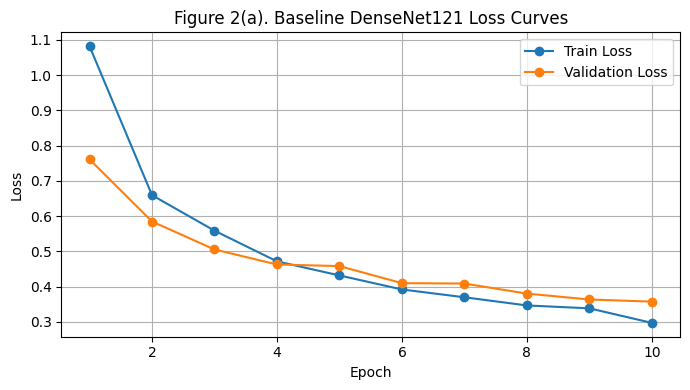

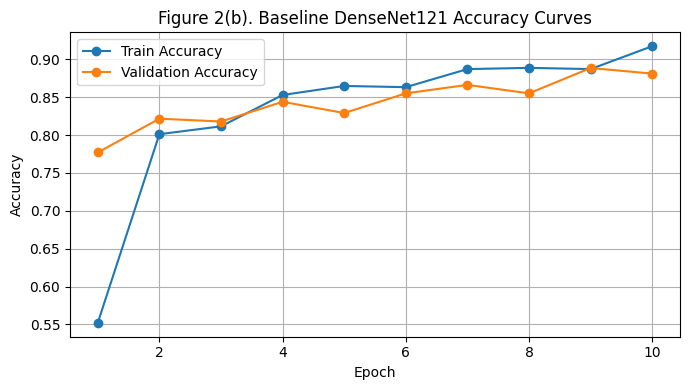

Baseline generalisation gap: 0.0603


In [32]:
# Plot learning curves for the baseline model
plot_history(
    baseline_history,
    model_name="Baseline DenseNet121",
    figure_no=2
)

# Print generalisation gap as a supporting metric
baseline_gap = generalisation_gap(baseline_history)

print(f"Baseline generalisation gap: {baseline_gap:.4f}")

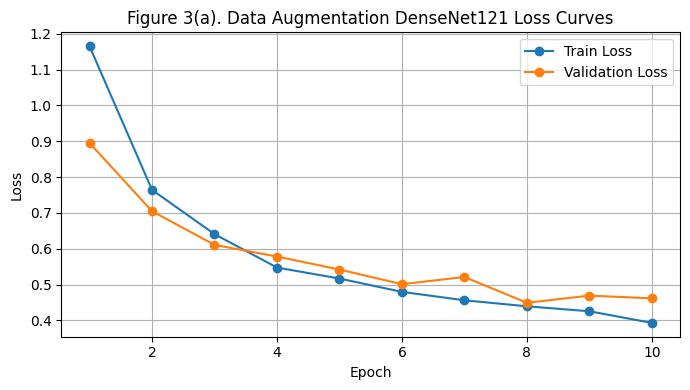

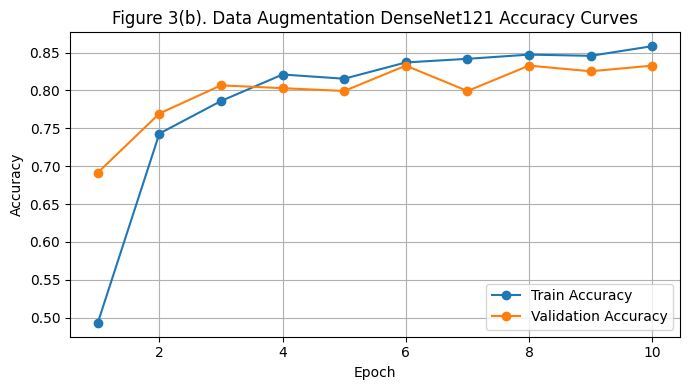

Data augmentation model generalisation gap: 0.0685


In [35]:
# Plot learning curves for the data augmentation model
plot_history(
    augmented_history,
    model_name="Data Augmentation DenseNet121",
    figure_no=3
)

# Print generalisation gap as a supporting metric
augmented_gap = generalisation_gap(augmented_history)

print(f"Data augmentation model generalisation gap: {augmented_gap:.4f}")

In [36]:
comparison_table = pd.DataFrame([
    create_result_row(
        setting_name="Baseline",
        model=baseline_model,
        history=baseline_history,
        loader=test_loader,
        criterion=criterion,
        device=device
    ),
    create_result_row(
        setting_name="+ Augmentation",
        model=augmented_model,
        history=augmented_history,
        loader=test_loader,
        criterion=aug_criterion,
        device=device
    )
])
print('Table 3. Comparison of Baseline and Data Augmentation Model Performance')
display(comparison_table)

Table 3. Comparison of Baseline and Data Augmentation Model Performance


,Setting,Accuracy,Macro-F1,Training time per epoch (s),Total training time (min)
0,Baseline,0.8593,0.863,10.46,1.74
1,+ Augmentation,0.8593,0.863,14.82,2.47


Use either the same total training time on the same hardware or the same number of optimiser steps as your approximate equal training budget. Briefly state any important hardware or pipeline differences.

| Setting | Accuracy | Macro-F1 | Training time per epoch (s) | Total training time (min) |
| --- | ---: | ---: | ---: | ---: |
| Baseline | 0.8593 | 0.863 | 10.46 | 1.74 |
| + Augmentation | 0.8593 | 0.863	 | 14.82 | 2.47 |



- **Short discussion**



The baseline and augmented models were compared using the same DenseNet121 architecture, the same splitting ratio, Adam optimiser, learning rate of 0.001, 32 batch sizes, and 10 training epochs. The learning curve showed that both models learn steadily, with a decrease in training and validation across each epoch. However, both models showed signs of overfitting, and the augmented model exhibited a slightly larger generalisation gap. This suggests that the complex image transformations made the learning task harder within the short 10-epoch limit.  Additionally, the augmented model achieved a similar accuracy and macro-F1 score compared to the baseline model, which reached 0.8593 and 0.8630, respectively. Moreover, the computational cost also increased with augmentation, in which the average training time per epoch rose from 10.46 seconds to 14.82 seconds. It also led to an increase in total training time from 1.74 to 2.47 minutes. Therefore, the extra augmentation cost was not clearly beneficial since it did not yield immediate performance gains on the same-domain TrashNet test set. However, augmentation remains useful for this waste classification problem, because the model stimulated real-world variation in object position, lighting orientation and scale. Accordingly, it may support better robustness in cross-domain environments.

## 3 Pipeline profiling

In [37]:
# Brief pipeline profiling
def profile_pipeline(model, loader, device, num_batches=10):
    model.eval()

    load_times = []
    transfer_times = []
    forward_times = []

    data_iter = iter(loader)

    with torch.no_grad():
        for _ in range(num_batches):
            # Measure data loading and preprocessing time
            start = time.time()
            xb, yb = next(data_iter)
            load_time = time.time() - start

            # Measure device transfer time
            start = time.time()
            xb = xb.to(device)
            yb = yb.to(device)
            transfer_time = time.time() - start

            # Measure model forward pass time
            start = time.time()
            _ = model(xb)
            forward_time = time.time() - start

            load_times.append(load_time)
            transfer_times.append(transfer_time)
            forward_times.append(forward_time)

    profiling_table = pd.DataFrame({
        "Pipeline step": [
            "Data loading and preprocessing",
            "Device transfer",
            "Model forward pass"
        ],
        "Average time per batch (seconds)": [
            round(sum(load_times) / len(load_times), 4),
            round(sum(transfer_times) / len(transfer_times), 4),
            round(sum(forward_times) / len(forward_times), 4)
        ]
    })

    return profiling_table

In [38]:
baseline_profile = profile_pipeline(
    model=baseline_model,
    loader=train_loader,
    device=device,
    num_batches=10
)

print("Table 4: Baseline pipeline profile")
display(baseline_profile)

Table 4: Baseline pipeline profile


,Pipeline step,Average time per batch (seconds)
0,Data loading and preprocessing,0.2335
1,Device transfer,0.0049
2,Model forward pass,0.0281


In [39]:
pipeline_profile = profile_pipeline(
    model=augmented_model,
    loader=aug_train_loader,
    device=device,
    num_batches=10
)

print("Table 5: Augmented pipeline profile")
display(pipeline_profile)

Table 5: Augmented pipeline profile


,Pipeline step,Average time per batch (seconds)
0,Data loading and preprocessing,0.2549
1,Device transfer,0.0018
2,Model forward pass,0.0209


- **Intepretations of Slowest step and mitigation**

Based on the profiling results, data loading and preprocessing was the slowest step and was considered the main bottleneck in both input pipelines. For the baseline model, this step took 0.2335 seconds per batch, which was much higher than 0.0049 seconds for device transfer and 0.0281 seconds for the model forward pass. In the augmented model, data loading and preprocessing increased to 0.2549 seconds per batch, while device transfer and the model forward pass remained low at 0.0018 and 0.0209 seconds, respectively. This shows that the added augmentation operations increased CPU preprocessing cost. To mitigate this bottleneck, I would increase num_workers to parallelise data loading and preprocessing.

# III Error analysis and domain generalisation

## 1 Failure analysis



In [41]:
# Show up to six misclassified images from the original held-out test split
# Choose the model for failure analysis
model_to_analyse = augmented_model

# Function to unnormalize image for display
def unnormalize_image(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image = image_tensor.cpu() * std + mean
    image = torch.clamp(image, 0, 1)

    image = image.permute(1, 2, 0).numpy()
    return image


# Function to collect misclassified images
def collect_misclassified_images(model, loader, device, class_names, max_images=6):
    model.eval()

    misclassified_images = []
    misclassified_records = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            preds = torch.argmax(logits, dim=1)

            wrong_indices = torch.where(preds != yb)[0]

            for idx in wrong_indices:
                true_label = yb[idx].item()
                predicted_label = preds[idx].item()

                misclassified_images.append({
                    "image": xb[idx].detach().cpu(),
                    "true_label": true_label,
                    "predicted_label": predicted_label
                })

                misclassified_records.append({
                    "True Class": class_names[true_label],
                    "Predicted Class": class_names[predicted_label]
                })

                if len(misclassified_images) >= max_images:
                    return misclassified_images, pd.DataFrame(misclassified_records)

    return misclassified_images, pd.DataFrame(misclassified_records)


# Collect six misclassified images from the original test split
misclassified_images, misclassified_table = collect_misclassified_images(
    model=model_to_analyse,
    loader=test_loader,
    device=device,
    class_names=class_names,
    max_images=6
)

# Display misclassified image summary table
print("Table 6: Error Analysis of Misclassified Samples from the Data Augmentation Model")
display(misclassified_table)

Table 6: Error Analysis of Misclassified Samples from the Data Augmentation Model


,True Class,Predicted Class
0,Metal,Glass
1,Glass,Metal
2,Glass,Plastic
3,Glass,Metal
4,Glass,Metal
5,Glass,Metal


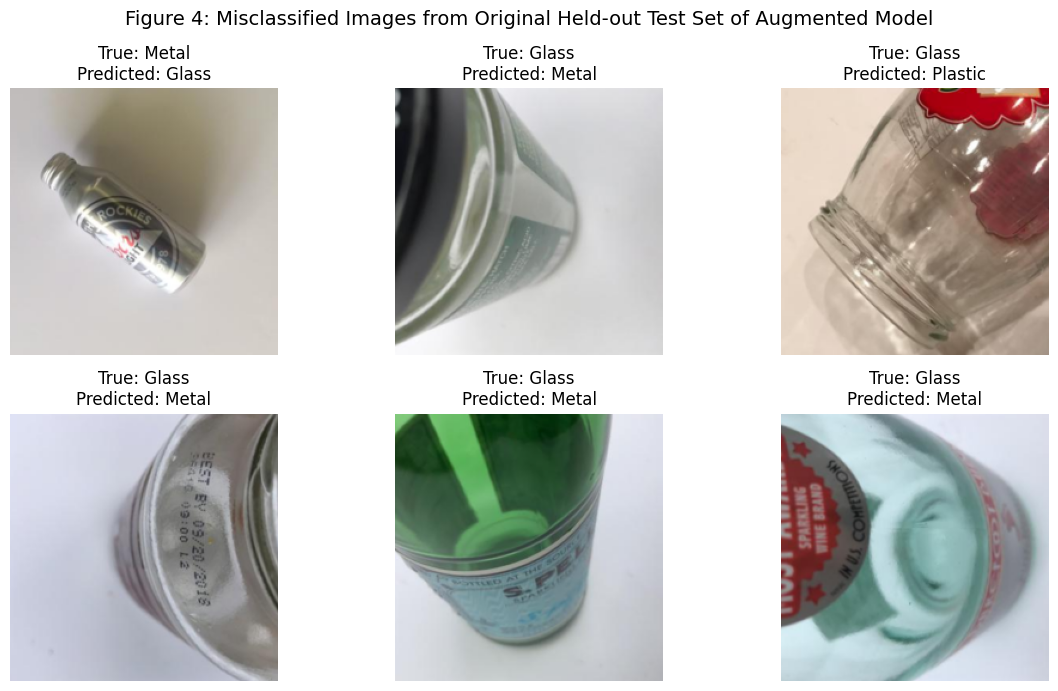

In [42]:
# Plot up to six misclassified images

num_images = len(misclassified_images)

plt.figure(figsize=(12, 7))

for i, item in enumerate(misclassified_images):
    image = unnormalize_image(item["image"])
    true_class = class_names[item["true_label"]]
    predicted_class = class_names[item["predicted_label"]]

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(f"True: {true_class}\nPredicted: {predicted_class}")
    plt.axis("off")

plt.suptitle("Figure 4: Misclassified Images from Original Held-out Test Set of Augmented Model", fontsize=14)
plt.tight_layout()
plt.show()

- **Observed pattern**


According to the misclassified images, most errors occurred in detecting glass and metal, with one glass item predicted as plastic. These failure patterns stem from unusual viewpoints and ambiguous material boundaries, such as transparent surfaces, curved bottle shapes, partial object views, and strong highlights. Specifically, four of six errors occurred when glasses were viewed top-down and heavily cropped with labels and bright highlights, making the surface appear metallic. Additionally, the horizontal object orientations, such as glass jars, demonstrate a failure to handle rotational variance. Similarly, the metal was misclassified because its cylindrical shape and reflective surface resembled a glass container. Consequently, these weaknesses revealed that the model relies heavily on standard object shapes, canonical orientations, and reflection rather than learning fundamental material textures.

## 2 New-domain test set


- **New-domain collection protocol**

To evaluate the model’s robustness against real-world domain shifts, a new-domain test set was created from the RealWaste dataset. The RealWaste dataset was collected at the Whyte's Gully Waste and Resource Recovery facility in Wollongong, which contained images of actual waste materials in real-world conditions (Single et al., 2023). To make the new-domain set comparable with four-class classification, I selected a subset of 402 images, which were distributed across four target classes. The new-domain image was only used for testing domain generalisation and kept strictly separate from the training and validation phases. Unlike the original dataset, RealWaste captures waste in its natural, damaged state on varied outdoor surfaces under diverse lighting. This provides a rigorous test of the model's ability to generalise beyond canonical object shapes and controlled indoor environments.

In [18]:
# Count images in each new-domain class folder
new_domain_counts = []

for class_name in selected_classes:
    # Handle class folder case-insensitively
    available_folders = os.listdir(new_domain_root)

    matched_folder = None
    for folder in available_folders:
        if folder.lower() == class_name.lower():
            matched_folder = folder
            break

    if matched_folder is None:
        raise FileNotFoundError(
            f"Folder not found for class: {class_name}. "
            f"Available folders are: {available_folders}"
        )

    folder_path = os.path.join(new_domain_root, matched_folder)

    count = len([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(valid_extensions)
        and os.path.isfile(os.path.join(folder_path, f))
    ])

    new_domain_counts.append({
        "Class": class_name.capitalize(),
        "Number of Images": count
    })

# Convert to DataFrame
new_domain_counts_df = pd.DataFrame(new_domain_counts)

# Add percentage column
total_new_domain_images = new_domain_counts_df["Number of Images"].sum()

new_domain_counts_df["Percentage (%)"] = (
    new_domain_counts_df["Number of Images"] / total_new_domain_images * 100
).round(2)

# Display summary table
print('Table 7.a :Class Distribution of the new Domain Test Set')
display(new_domain_counts_df)

# Display total number of images
print(f"Total number of new-domain images: {total_new_domain_images}")

Table 7.a :Class Distribution of the new Domain Test Set


,Class,Number of Images,Percentage (%)
0,Cardboard,98,24.38
1,Glass,101,25.12
2,Metal,105,26.12
3,Plastic,98,24.38


Total number of new-domain images: 402


| Aspect | Original test set | New-domain test set |
| --- | --- | --- |
| Source | TrashNet held-out test split | RealWaste subset dataset |
| Class counts | 270 images across cardboard (60), glass(75), metal(62), and plastic(73) | 402 images across cardboard (98), glass(101), metal(105), and plastic(98) |
| Background | Clean, plain, and light-coloured (white/netural) backgrounds |Realistic backgrounds, including floor, concrete, and texture surfaces (dirt) |
| Lighting | Controlled and relatively consistent indoor lighting | More varied lighting, brightness, and reflections |
| Viewpoint / scale | Objects are generally isolateduncentered and varied position with moderate variation in angle and scale| Objectes are more centered framing and greater variation in orientation, angle and scale  |
| Other relevant differences | Objects are generally more cleaner with less damaged or event without damaged, partially cropped | Objects may be damaged, crushed, dirty, or photographed in real-world conditions |

In [14]:
# Google Drive file link
file_url = "https://drive.google.com/file/d/14n1bzNS5TEIS43Yo3avaARb6j8Ce7f0D/view?usp=sharing"

# Extract file ID from your link
file_id = "14n1bzNS5TEIS43Yo3avaARb6j8Ce7f0D"

# Define zip download path
zip_path = "/content/new_domain_testset.zip"

# Define unzip folder
extract_path = "/content/new_domain_testset"

# Download ZIP file from Google Drive
gdown.download(
    id=file_id,
    output=zip_path,
    quiet=False
)

# Remove old extracted folder if it already exists
if os.path.exists(extract_path):
    import shutil
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

# Unzip file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file extracted successfully.")
print("Extracted folders/files:")
print(os.listdir(extract_path))

Downloading...
From (original): https://drive.google.com/uc?id=14n1bzNS5TEIS43Yo3avaARb6j8Ce7f0D
From (redirected): https://drive.google.com/uc?id=14n1bzNS5TEIS43Yo3avaARb6j8Ce7f0D&confirm=t&uuid=2cd53088-606e-4d97-85f8-bc01e61cdc38
To: /content/new_domain_testset.zip
100%|██████████| 58.6M/58.6M [00:00<00:00, 107MB/s] 


ZIP file extracted successfully.
Extracted folders/files:
['realwaste-main']


In [15]:
# Use the same selected classes as Task 1
selected_classes = ["cardboard", "glass", "metal", "plastic"]
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# This is the folder after unzip
extract_path = "/content/new_domain_testset"

def find_dataset_root(base_path, selected_classes):
    selected_lower = [class_name.lower() for class_name in selected_classes]

    for current_root, dirs, files in os.walk(base_path):
        dirs_lower = [folder.lower() for folder in dirs]

        if all(class_name in dirs_lower for class_name in selected_lower):
            return current_root

    raise FileNotFoundError(
        "Could not find a folder containing all selected class folders: "
        + ", ".join(selected_classes)
    )

# Automatically detect the real dataset root
new_domain_root = find_dataset_root(extract_path, selected_classes)

print("Detected new-domain dataset root:")
print(new_domain_root)
print("Available class folders:")
print(os.listdir(new_domain_root))

Detected new-domain dataset root:
/content/new_domain_testset/realwaste-main/RealWaste
Available class folders:
['Plastic', 'Glass', 'Metal', 'Cardboard']


In [17]:
# Count number of images per class in test set
test_counts = Counter(y_test)

test_counts_list = []

for class_index, class_name in enumerate(class_names):
    count = test_counts.get(class_index, 0)

    test_counts_list.append({
        "Class": class_name.capitalize(),
        "Number of Images": count
    })

# Convert to DataFrame
test_counts_df = pd.DataFrame(test_counts_list)

# Add percentage column
total_test_images = test_counts_df["Number of Images"].sum()

test_counts_df["Percentage (%)"] = (
    test_counts_df["Number of Images"] / total_test_images * 100
).round(2)

# Display summary table
print('Table 7.b :Class Distribution of the Old Test Set')
display(test_counts_df)

# Display total number of images
print(f"Total number of test images: {total_test_images}")

Table 7.b :Class Distribution of the Old Test Set


,Class,Number of Images,Percentage (%)
0,Cardboard,60,22.22
1,Glass,75,27.78
2,Metal,62,22.96
3,Plastic,73,27.04


Total number of test images: 270


In [46]:
# Define a separate dataset class for the new-domain dataset only.
class NewDomainWasteDataset(Dataset):
    def __init__(self, root_dir, selected_classes, transform=None):
        self.root_dir = root_dir
        self.selected_classes = selected_classes
        self.transform = transform
        self.samples = []

        # Keep the same class order as Task 1
        self.class_to_idx = {
            class_name: idx for idx, class_name in enumerate(selected_classes)
        }

        available_folders = sorted(os.listdir(root_dir))

        for class_name in selected_classes:
            matched_folder = None

            # Match folder names case-insensitively
            for folder in available_folders:
                if folder.lower() == class_name.lower():
                    matched_folder = folder
                    break

            if matched_folder is None:
                raise FileNotFoundError(
                    f"Folder not found for class: {class_name}. "
                    f"Available folders are: {available_folders}"
                )

            folder_path = os.path.join(root_dir, matched_folder)

            # Use sorted() to keep image order stable across runs
            for file_name in sorted(os.listdir(folder_path)):
                if file_name.lower().endswith(valid_extensions):
                    image_path = os.path.join(folder_path, file_name)

                    if os.path.isfile(image_path):
                        self.samples.append(
                            (image_path, self.class_to_idx[class_name])
                        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label


In [47]:
# Load new-domain dataset using the same evaluation preprocessing.
new_domain_dataset = NewDomainWasteDataset(
    root_dir=new_domain_root,
    selected_classes=selected_classes,
    transform=baseline_transform
)

new_domain_loader = DataLoader(
    new_domain_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("New-domain test images:", len(new_domain_dataset))


New-domain test images: 402


- Show several representative images from both the original test set and the new-domain test set

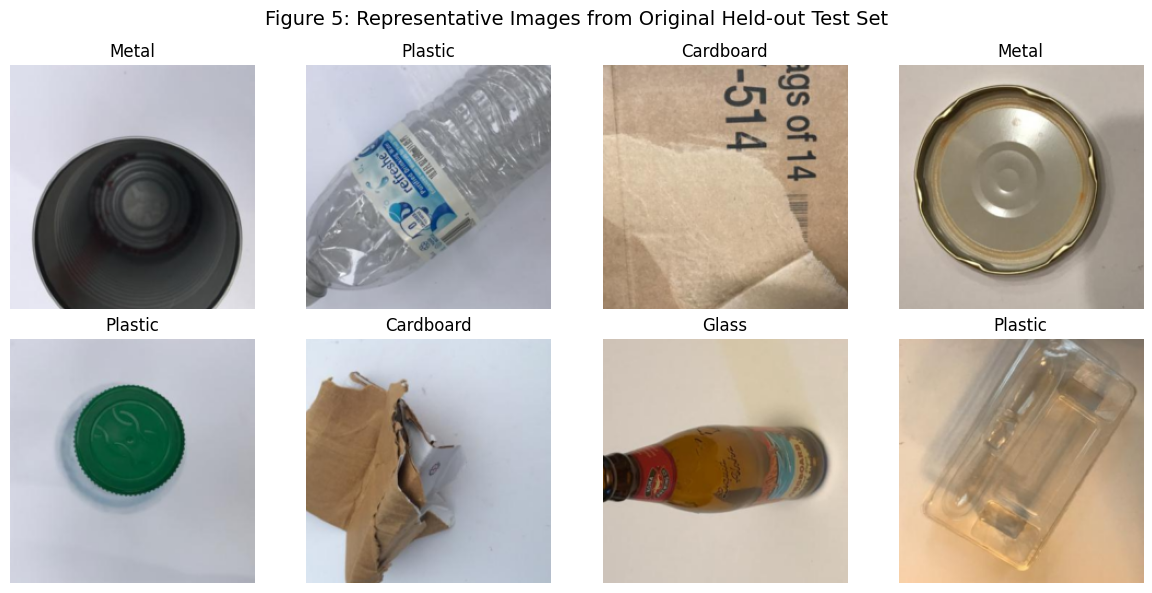

In [49]:
# Function to unnormalize image for display
def unnormalize_image(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image = image_tensor.cpu() * std + mean
    image = torch.clamp(image, 0, 1)

    image = image.permute(1, 2, 0).numpy()
    return image


# Function to show sample images from a dataset
def show_sample_images(dataset, title, class_names, num_images=8):
    plt.figure(figsize=(12, 6))

    indices = np.linspace(0, len(dataset) - 1, num_images, dtype=int)

    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        image = unnormalize_image(image)

        plt.subplot(2, 4, i + 1)
        plt.imshow(image)
        plt.title(class_names[label])
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# Show representative images from original held-out test set
show_sample_images(
    dataset=test_dataset,
    title="Figure 5: Representative Images from Original Held-out Test Set",
    class_names=class_names,
    num_images=8
)



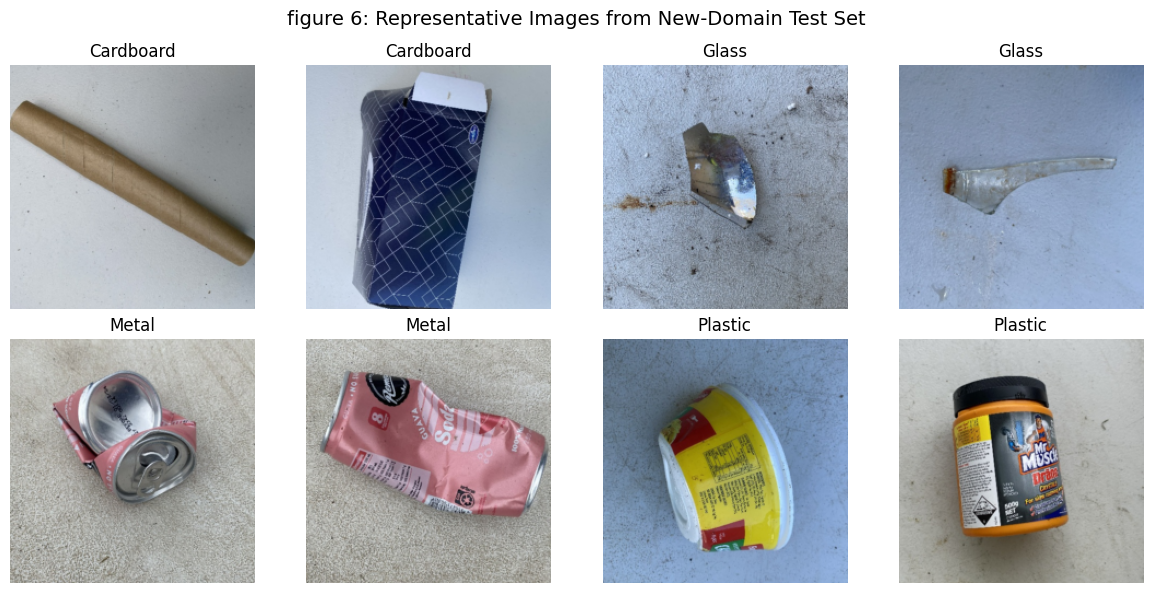

In [50]:
# Show representative images from new-domain test set
show_sample_images(
    dataset=new_domain_dataset,
    title="figure 6: Representative Images from New-Domain Test Set",
    class_names=class_names,
    num_images=8
)

## 3 Targeted improvement




- **Chosen intervention**

To address the failure analysis, this targeted intervention revised the augmentation pipeline to preserve structural integrity while enhancing robustness to lighting variation. Previously, extreme cropping, vertical flipping, and rotation destroyed critical object shapes, exacerbating confusion between metal and glass. The revised pipeline replaces aggressive cropping and affine transformations with gentle resizing, eliminates vertical flips, and restricts rotation to maintain realistic object orientations. Additionally, colour jitter and random autocontract are applied to better simulate new-domain conditions, thereby helping address the model’s struggle with lighting-related variation and material ambiguity. By minimising destructive geometric distortions and introducing realistic lighting shifts, the pipeline preserves vital cues, such as shape, transparency, and reflective texture. This was expected to encourage the model to learn more invariant material features and improve generalisation to real-world domain shifts.

In [51]:
# Implement the targeted transform
targeted_transform = T.Compose([
    T.ToImage(),

    # Preserve object structure while allowing small scale variation
    T.Resize(
        size=int(IMAGE_SIZE * 1.08),
        antialias=True
    ),

    # Small crop variation
    T.RandomCrop(
        size=(IMAGE_SIZE, IMAGE_SIZE),
        padding=3
    ),

    # Realistic orientation variation
    T.RandomHorizontalFlip(p=0.5),

    # Keep geometry very mild to avoid damaging glass/metal/plastic cues
    T.RandomAffine(
        degrees=3,
        translate=(0.02, 0.02),
        scale=(0.98, 1.03)
    ),

    # Slightly stronger lighting/contrast variation for new-domain shift
    T.ColorJitter(
        brightness=0.15,
        contrast=0.22,
        saturation=0.06,
        hue=0.002
    ),

    # Slightly higher probability than before, but still low
    T.RandomAutocontrast(p=0.05),

    T.ToDtype(torch.float32, scale=True),

    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [52]:
# Create targeted augmented full dataset for training only.
targeted_full_dataset = WasteDataset(
    root_dir=root,
    selected_classes=selected_classes,
    transform=targeted_transform
)

# Use the same training indices from Task 1.2
targeted_train_dataset = Subset(targeted_full_dataset, X_train)

print("Targeted training images:", len(targeted_train_dataset))


Targeted training images: 1257


In [53]:
# Set generator for reproducibility
g_targeted = torch.Generator()
g_targeted.manual_seed(SEED)

targeted_train_loader = DataLoader(
    targeted_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g_targeted,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


In [54]:
# Reset seeds before creating targeted model
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Create new DenseNet121 model for targeted augmentation experiment
targeted_augmented_model = DenseNet121Baseline(output_dim=output_dim)
targeted_augmented_model = targeted_augmented_model.to(device)

print("Targeted augmented DenseNet121 model created.")
print("Final classifier layer:")
print(targeted_augmented_model.network.classifier)


Targeted augmented DenseNet121 model created.
Final classifier layer:
Linear(in_features=1024, out_features=4, bias=True)


In [55]:
targeted_criterion = nn.CrossEntropyLoss()

targeted_optimizer = optim.Adam(
    targeted_augmented_model.network.classifier.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0
)

In [56]:
targeted_augmented_model, targeted_augmented_history = train_model(
    model=targeted_augmented_model,
    train_loader=targeted_train_loader,
    val_loader=val_loader,
    criterion=targeted_criterion,
    optimizer=targeted_optimizer,
    device=device,
    epochs=EPOCHS
)

Epoch 01 | train_loss=1.1378 | val_loss=0.8173 | train_acc=0.5155 | val_acc=0.7398 | train_macro_f1=0.5196 | val_macro_f1=0.7507 | time=18.04s
Epoch 02 | train_loss=0.7308 | val_loss=0.6224 | train_acc=0.7605 | val_acc=0.7918 | train_macro_f1=0.7646 | val_macro_f1=0.7978 | time=17.22s
Epoch 03 | train_loss=0.6101 | val_loss=0.5435 | train_acc=0.8011 | val_acc=0.8253 | train_macro_f1=0.8050 | val_macro_f1=0.8300 | time=22.56s
Epoch 04 | train_loss=0.5246 | val_loss=0.5070 | train_acc=0.8242 | val_acc=0.8216 | train_macro_f1=0.8282 | val_macro_f1=0.8246 | time=19.50s
Epoch 05 | train_loss=0.4945 | val_loss=0.4889 | train_acc=0.8417 | val_acc=0.8253 | train_macro_f1=0.8447 | val_macro_f1=0.8283 | time=20.84s
Epoch 06 | train_loss=0.4449 | val_loss=0.4518 | train_acc=0.8473 | val_acc=0.8327 | train_macro_f1=0.8500 | val_macro_f1=0.8386 | time=25.74s
Epoch 07 | train_loss=0.4273 | val_loss=0.4423 | train_acc=0.8504 | val_acc=0.8401 | train_macro_f1=0.8530 | val_macro_f1=0.8432 | time=25.24s

In [57]:
# Before targeted improvement: augmented model on original test set
aug_test_loss, aug_test_acc, aug_test_macro_f1, aug_test_true, aug_test_pred = evaluate_model(
    augmented_model,
    test_loader,
    criterion,
    device
)

# Before targeted improvement: augmented model on new-domain test set
aug_new_loss, aug_new_acc, aug_new_macro_f1, aug_new_true, aug_new_pred = evaluate_model(
    augmented_model,
    new_domain_loader,
    criterion,
    device
)

# After targeted improvement: targeted augmented model on original test set
target_test_loss, target_test_acc, target_test_macro_f1, target_test_true, target_test_pred = evaluate_model(
    targeted_augmented_model,
    test_loader,
    targeted_criterion,
    device
)

# After targeted improvement: targeted augmented model on new-domain test set
target_new_loss, target_new_acc, target_new_macro_f1, target_new_true, target_new_pred = evaluate_model(
    targeted_augmented_model,
    new_domain_loader,
    targeted_criterion,
    device
)

In [58]:
# Print the comparision table
task3_3_results = pd.DataFrame({
    "Model variant": [
        "Before targeted improvement",
        "After targeted improvement"
    ],
    "Original test accuracy": [
        round(aug_test_acc, 4),
        round(target_test_acc, 4)
    ],
    "Original test macro-F1": [
        round(aug_test_macro_f1, 4),
        round(target_test_macro_f1, 4)
    ],
    "New-domain accuracy": [
        round(aug_new_acc, 4),
        round(target_new_acc, 4)
    ],
    "New-domain macro-F1": [
        round(aug_new_macro_f1, 4),
        round(target_new_macro_f1, 4)
    ]
})

print('Table 8. Performance Comparison of Targeted Improvement on Original and New-Domain Test Sets')
display(task3_3_results)

Table 8. Performance Comparison of Targeted Improvement on Original and New-Domain Test Sets


,Model variant,Original test accuracy,Original test macro-F1,New-domain accuracy,New-domain macro-F1
0,Before targeted improvement,0.8593,0.8630,0.5597,0.5421
1,After targeted improvement,0.8704,0.8738,0.5522,0.5353


- **Final discussion**

| Model variant | Original test accuracy | Original test macro-F1 | New-domain accuracy | New-domain macro-F1 |
| --- | ---: | ---: | ---: | ---: |
| Before targeted improvement | 0.8593 | 0.8630 | 0.5597 | 0.5421 |
| After targeted improvement | 0.8704 | 0.8738 | 0.5522 | 0.5353 |




The experimental results demonstrate a clear trade-off between specialised accuracy and generalisation robustness. Specifically, the model’s performance improved from 0.8593 to 0.8704 in accuracy and from 0.8630 to 0.8738 in macro-F1. This suggests that the revised augmentation enhanced the model’s ability to learn domain-specific and material-related features from the original dataset. By reducing destructive transformations, the model preserved useful visual cues, such as object shape, transparency, texture, and other representative features. However, the intervention did not improve robustness on the RealWaste test set. The accuracy and macro-F1 score of the model's performance decreased slightly from 0.5597 to 0.5522 and from 0.5421 to 0.5353, respectively.

This result suggests that the main weakness was not only sensitivity to object orientation or lighting variation, but also a broader domain gap between TrashNet and Realwaste. Specifically, the RealWaste images contain more realistic features, including dirt, damaged objects, varied backgrounds, uncontrolled lighting and less consistent object framing. These differences appear larger than the variation that was stimulated by the revised augmentation pipeline. Additionally, the likely change in model behaviour is that the model gets better at recognising cleaner TrashNet-style material features. However, it struggles when those features appear in messier real-world conditions. This highlights the critical generalisation trade-off, in which preserving object structure improves the model accuracy in the original test, but it also limits the model's ability to handle the variation found in real-world landfill waste. Therefore, synthetic augmentation alone was insufficient to overcome large domain gaps. Adding a small amount of real-world training data or using strong domain-specific preprocessing to reduce background noise should be considered for further improvement.
